In [6]:
import tensorflow as tf
import numpy as np
from tensorflow.keras import datasets, layers, models

In [7]:
input_shape = (28, 28, 1)
num_classes = 10

In [8]:
(x_train, y_train), (x_test, y_test) = datasets.mnist.load_data()

In [9]:
x_train_4d = x_train[..., tf.newaxis] # 3D -> 4D
print(x_train_4d.shape, x_train.shape, x_train_4d.dtype)

(60000, 28, 28, 1) (60000, 28, 28) uint8


In [10]:
x_train_4d = x_train_4d / 255.0 # scaling to [0,1]
print(np.max(x_train_4d), np.min(x_train_4d))

1.0 0.0


In [13]:
model = models.Sequential([
    layers.Input(shape=(28, 28, 1)),
    layers.Conv2D(32, kernel_size=(3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Conv2D(64, kernel_size=(3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
], name="My_Sequential_Model")

In [16]:
model.summary()

Model: "My_Sequential_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 28, 28, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 14, 14, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 14, 14, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 7, 7, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 3136)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         401,536 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,264,928 (4.83 MB)

 Trainable params: 421,642 (1.61 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 843,286 (3.22 MB)

In [14]:
model.compile(optimizer=tf.keras.optimizers.Adam(),
              loss = 'sparse_categorical_crossentropy', 
              metrics=['accuracy'])

In [15]:
num_epochs = 3
bs = 32
hist = model.fit(x_train_4d, y_train, batch_size=bs, shuffle=True, epochs=num_epochs)

Epoch 1/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - accuracy: 0.9619 - loss: 0.1227
Epoch 2/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9878 - loss: 0.0385
Epoch 3/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - accuracy: 0.9920 - loss: 0.0266


In [20]:
def one_hot_encoding(class_num, class_gt):
    one_hot = np.zeros(class_num, dtype='uint16')
    one_hot[class_gt] = 1
    return one_hot

In [21]:
a = one_hot_encoding(num_classes, 2)
print(a, a.dtype)

[0 0 1 0 0 0 0 0 0 0] uint16


In [37]:
y_train.dtype

dtype('uint8')

In [26]:
one_hot_y_train = []
for label in y_train:
    one_hot_y_train.append(one_hot_encoding(num_classes, label))
one_hot_y_train = np.array(one_hot_y_train)

In [31]:
len(one_hot_y_train), one_hot_y_train[1], y_train.shape

(60000, array([1, 0, 0, 0, 0, 0, 0, 0, 0, 0], dtype=uint16), (60000,))

In [40]:
model.compile(optimizer=tf.keras.optimizers.Adam(),
              loss = 'categorical_crossentropy', # sparse 빼야 돌아감
              metrics=['accuracy'])

In [39]:
num_epochs = 3
bs = 32
hist = model.fit(x_train_4d, one_hot_y_train, batch_size=bs, shuffle=True, epochs=num_epochs)

Epoch 1/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9929 - loss: 0.0206
Epoch 2/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9954 - loss: 0.0135
Epoch 3/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9963 - loss: 0.0109


In [42]:
save_path = './save/cpk.weights.h5'
checkpoint = tf.keras.callbacks.ModelCheckpoint(save_path, monitor='accuracy', verbose=1, save_weights_only=True, mode='max')

In [43]:
num_epochs = 3
bs = 32
hist = model.fit(x_train_4d, one_hot_y_train, batch_size=bs, shuffle=True, epochs=num_epochs, callbacks=[checkpoint])

Epoch 1/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9971 - loss: 0.0092
Epoch 1: saving model to ./save/cpk.weights.h5

Epoch 1: finished saving model to ./save/cpk.weights.h5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9967 - loss: 0.0103
Epoch 2/3
1867/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9983 - loss: 0.0057
Epoch 2: saving model to ./save/cpk.weights.h5

Epoch 2: finished saving model to ./save/cpk.weights.h5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9976 - loss: 0.0075
Epoch 3/3
1866/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9984 - loss: 0.0049
Epoch 3: saving model to ./save/cpk.weights.h5

Epoch 3: finished saving model to ./save/cpk.weights.h5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9978 - loss: 0.0064


In [45]:
new_model = models.Sequential([
    layers.Input(shape=(28, 28, 1)),
    layers.Conv2D(32, kernel_size=(3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Conv2D(64, kernel_size=(3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
    ], name="My_Sequential_Model")

In [46]:
new_model.load_weights(save_path)

In [47]:
x_train_4d_1000 = x_train_4d[0:1000]
one_hot_y_train_1000 = one_hot_y_train[:1000]

In [48]:
import math as m

In [50]:
def scheduler(epoch):
    if epoch < 10:
        return 0.001
    else:
        return 0.001 * m.exp(0.1*(10-epoch))

In [51]:
lr_scheduler = tf.keras.callbacks.LearningRateScheduler(scheduler)

In [52]:
save_path = './save/cpk.weights.h5'
checkpoint = tf.keras.callbacks.ModelCheckpoint(save_path, monitor='accuracy', verbose=1, save_weights_only=True, mode='max')

In [53]:
model.compile(optimizer=tf.keras.optimizers.Adam(),
              loss = 'categorical_crossentropy',
              metrics=['accuracy'])

In [54]:
num_epochs = 20
bs = 32
hist = model.fit(x_train_4d_1000, one_hot_y_train_1000, batch_size=bs, shuffle=True, epochs=num_epochs,
                 callbacks=[checkpoint, lr_scheduler])

Epoch 1/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 1.0000 - loss: 0.0016
Epoch 1: saving model to ./save/cpk.weights.h5

Epoch 1: finished saving model to ./save/cpk.weights.h5
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - accuracy: 1.0000 - loss: 0.0016 - learning_rate: 0.0010
Epoch 2/20
29/32 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 1.0000 - loss: 4.8831e-05
Epoch 2: saving model to ./save/cpk.weights.h5

Epoch 2: finished saving model to ./save/cpk.weights.h5
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 1.0000 - loss: 2.2078e-05 - learning_rate: 0.0010
Epoch 3/20
31/32 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 1.0000 - loss: 1.4049e-05
Epoch 3: saving model to ./save/cpk.weights.h5

Epoch 3: finished saving model to ./save/cpk.weights.h5
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 1.0000 - loss: 8.3396e-06 - learning_rate: 0.0010
Epoch 4/20
31/32 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 1.0000 - loss: 4.3131e-06
Epoch 4: saving model to ./save/cpk.

In [55]:
x_test.shape, y_test.shape

((10000, 28, 28), (10000,))

In [59]:
x_test_4d = x_test[..., tf.newaxis]
x_test_4d = x_test_4d / 255.0
print(x_test_4d.shape, np.max(x_test_4d))

(10000, 28, 28, 1) 1.0


In [60]:
one_hot_y_test = []
for label in y_test:
    one_hot_y_test.append(one_hot_encoding(num_classes, label))
one_hot_y_test = np.array(one_hot_y_test)
print(one_hot_y_test.shape)

(10000, 10)


In [61]:
model.evaluate(x_test_4d, one_hot_y_test, batch_size = 32) 

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.9919 - loss: 0.0407


[0.040730930864810944, 0.9919000267982483]

In [62]:
x_test_4d[0].shape

(28, 28, 1)

In [70]:
pred = model.predict(x_test_4d[0:2])
print(pred, pred.shape)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
[[6.3099043e-24 6.0638669e-14 1.2676188e-16 8.4143359e-14 4.9746495e-15
  2.9819383e-18 4.2769812e-22 1.0000000e+00 5.2251040e-19 8.5094948e-10]
 [1.2103374e-22 7.5090960e-19 1.0000000e+00 2.6575627e-30 3.9487539e-26
  3.1175185e-34 5.8758513e-23 9.9541693e-25 6.5520111e-23 2.2077761e-28]] (2, 10)


In [66]:
import matplotlib.pyplot as plt

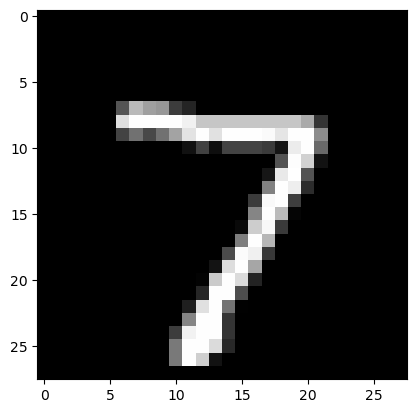

In [67]:
plt.imshow(x_test_4d[0:1].reshape(28, 28), 'gray')
plt.show()